## K-Means Clustering

K-means is the most popular and well-known clustering 
algorithm
Preview: Docs An algorithm is a formal process used to solve a problem. They can be represented in several formats but are usually represented in pseudocode in order to communicate the process by which the algorithms solve the problems they were created to tackle.
,and it tries to address these two questions.

1. The “k” refers to the number of clusters (groups) we expect to find in a dataset.
2. The “Means” refers to the average distance of data to each cluster center, also known as the centroid, which we are trying to minimize.

It is an iterative approach:

1. Place k random centroids for the initial clusters.
2. Assign data samples to the nearest centroid.
3. Calculate new centroids based on the above-assigned data samples.
4. Repeat Steps 2 and 3 until convergence.
5. Convergence occurs when points don’t move between clusters and centroids stabilize. This iterative process of updating clusters and centroids is called training.

Once we are happy with our clusters, we can take a new unlabeled datapoint and quickly assign it to the appropriate cluster. This is called inference.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from copy import deepcopy 
#Need deepcopy for centroid updates

In [6]:
iris = datasets.load_iris()
samples = iris.data

# Using sepal length & width
x = samples[:, 0]
y = samples[:, 1]
sepal_length_width = np.array(list(zip(x, y)))

In [17]:
# Step 1: Place K random centroids
k = 3
centroids_x = np.random.uniform(min(x), max(x), size=k)
centroids_y = np.random.uniform(min(y), max(y), size=k)
centroids = np.array(list(zip(centroids_x, centroids_y)))
print("Checking the centroid_x array:\n",centroids_x)
print("\nChecking the centroid_y array:\n",centroids_y)
print("\nChecking the complete centroids array:\n",centroids)



Checking the centroid_x array:
 [7.0627956  4.96374046 6.86823499]

Checking the centroid_y array:
 [3.25631246 2.0088951  2.10171663]

Checking the complete centroids array:
 [[7.0627956  3.25631246]
 [4.96374046 2.0088951 ]
 [6.86823499 2.10171663]]


In [19]:
# Distance function
def distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# Assign sample to nearest centroid
def assign_to_centroid(sample, centroids):
    distances = [distance(sample, c) for c in centroids]
    return np.argmin(distances)

# K-Means loop
max_iters = 100
error = np.inf

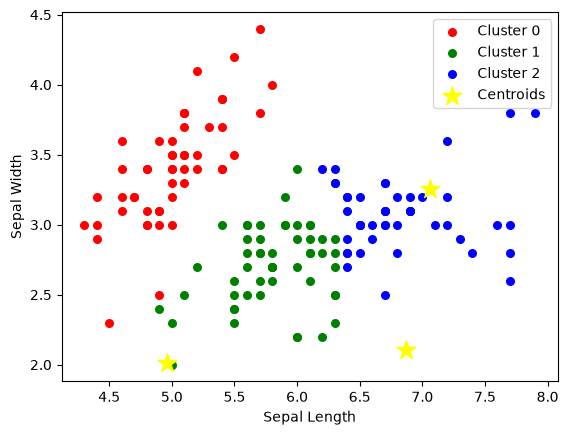

In [21]:
# Plot final clusters
colors = ['r', 'g', 'b']
for i in range(k):
    points = sepal_length_width[labels == i]
    plt.scatter(points[:, 0], points[:, 1], s=30, c=colors[i], label=f'Cluster {i}')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200, c='yellow', label='Centroids')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.show()

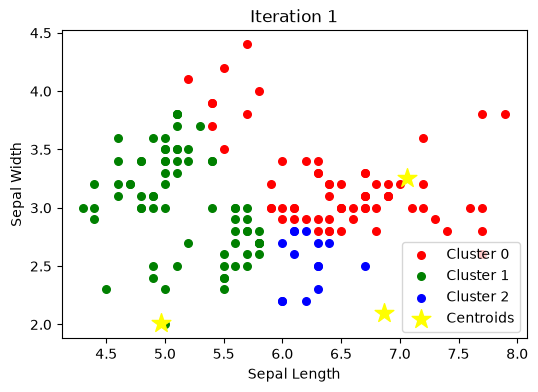

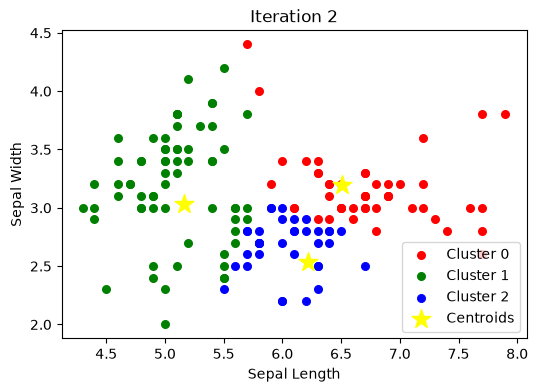

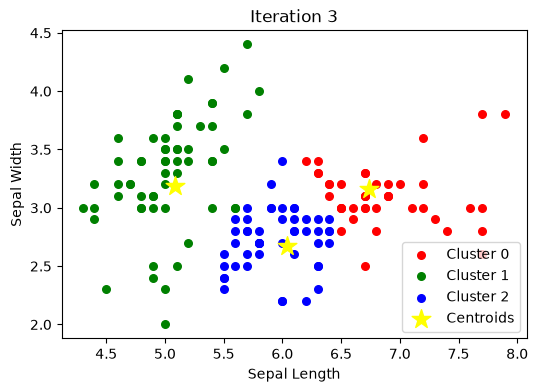

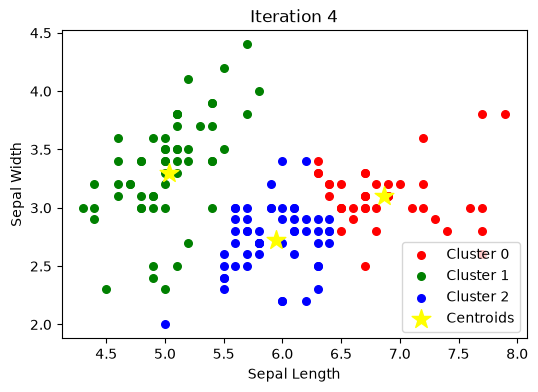

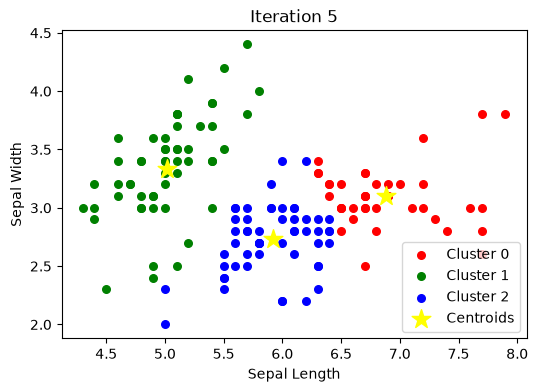

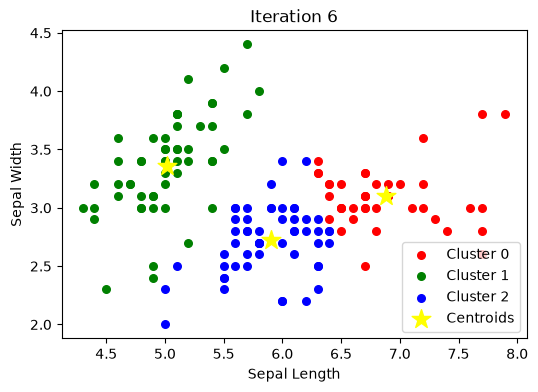

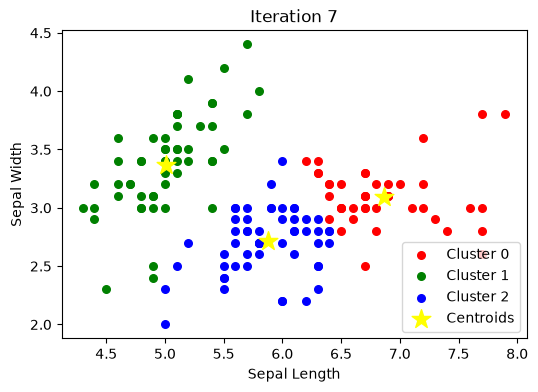

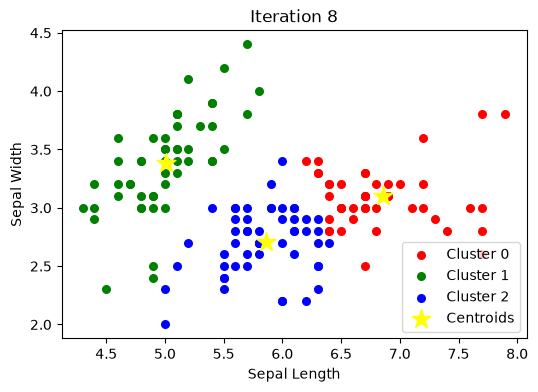

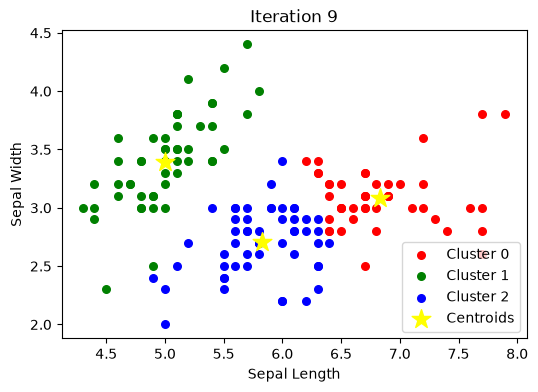

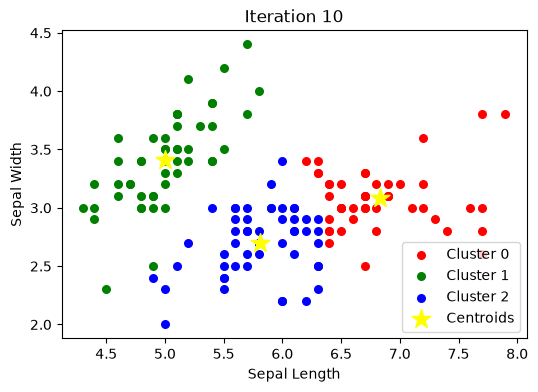

In [23]:
max_iters = 10
colors = ['r', 'g', 'b']

for it in range(max_iters):
    # Step 2: Assign samples
    labels = np.array([assign_to_centroid(p, centroids) for p in sepal_length_width])

    # Plot current iteration
    plt.figure(figsize=(6, 4))
    for i in range(k):
        points = sepal_length_width[labels == i]
        plt.scatter(points[:, 0], points[:, 1], s=30, c=colors[i], label=f'Cluster {i}')
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='*', s=200, c='yellow', label='Centroids')
    plt.title(f'Iteration {it+1}')
    plt.xlabel('Sepal Length')
    plt.ylabel('Sepal Width')
    plt.legend()
    plt.show()
        # Step 3: Update centroids
    centroids_old = deepcopy(centroids)
    for i in range(k):
        points = sepal_length_width[labels == i]
        if len(points) > 0:
            centroids[i] = np.mean(points, axis=0)

    # Convergence check
    if np.linalg.norm(centroids - centroids_old) < 1e-6:
        print(f'Converged at iteration {it+1}')
        break